In [183]:
import numpy as np
import scipy.stats as ss
import scipy as sp
import matplotlib.pyplot as plt 
import time

# 1-4

In [184]:
def Monte_carlo(N,seed= 30):
    np.random.seed(seed)
    U= np.random.uniform(0,1,N)
    samples=  np.exp(U)
    X= np.mean(samples)
    return X, np.var(samples,ddof=1)

def Antithetic(N,seed= 30):
    np.random.seed(seed)
    U= np.random.uniform(0,1,N)
    samples=  (np.exp(U)+np.exp(1-U))/2
    X= np.sum(samples)/N
    return X, np.var(samples,ddof=1)

def Control_estimator(N,seed= 30):
    np.random.seed(seed)
    U= np.random.uniform(0,1,N)
    X = np.exp(U)                 
    Y = U
    c = -np.cov(X, Y, ddof=1)[0, 1] / np.var(Y,ddof=1)  
    Z = X + c*(Y - 1/2) 
    return np.mean(Z),np.var(Z,ddof=1)

def straified_sampling(N,seed= 30):
    np.random.seed(seed)
    j = np.arange(N)                
    U = np.random.uniform(0, 1, N) # bar lav en lang arrayt
    x = (j+U)/N                 
    W = np.exp(x)
    return np.mean(W),np.var(W,ddof=1)                

In [185]:
N= 1000000
Monte_carlo(N),Antithetic(N),Control_estimator(N),straified_sampling(N)


((np.float64(1.7182569945948385), np.float64(0.24197323539157725)),
 (np.float64(1.7182754232489406), np.float64(0.003913625338182866)),
 (np.float64(1.718271662689828), np.float64(0.003938980978897104)),
 (np.float64(1.7182818285664943), np.float64(0.24203584999818528)))

In [186]:
np.exp(1)-1

np.float64(1.718281828459045)

# 5 

# 6

# 7

In [187]:
def Monte_carl_7(a,N):
    Z= np.random.normal(0,1,size=N)
    X= Z>a 
    return np.mean(X),np.var(X,ddof=1)  

In [188]:
def is_estimate_7(a,N,sigma=1):
    Y = np.random.normal(a,sigma,size=N)    
    h = lambda x: x>a
    X = h(Y)*ss.norm.pdf(Y,loc=0,scale=1)/ss.norm.pdf(Y,loc=a,scale=sigma)
    return np.mean(X),np.var(X,ddof=1)

In [189]:
Monte_carl_7(1,100000)

(np.float64(0.16089), np.float64(0.13500575795757958))

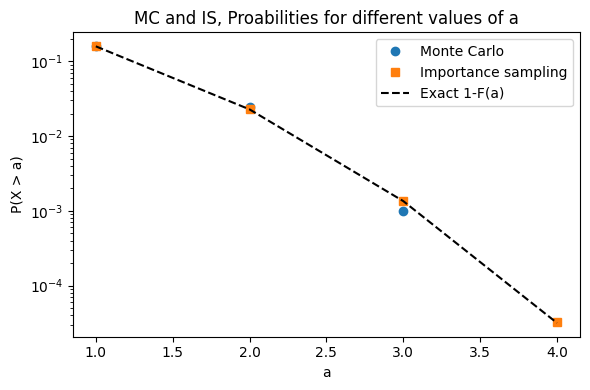

In [204]:
np.random.seed(40)
k= 4
monte = np.zeros(k)
correct = np.zeros_like(monte)
is_estimate = np.zeros_like(monte)
atest = np.array([1,2,3,4])
for i in range(k):
    monte[i], var  = Monte_carl_7(atest[i],10_000)
    is_estimate[i], var  = is_estimate_7(atest[i],10_000) 
    correct[i] = 1- ss.norm.cdf(atest[i])

plt.figure(figsize=(6,4))
plt.plot(atest, monte, 'o', label='Monte Carlo')
plt.plot(atest, is_estimate, 's', label='Importance sampling')
plt.plot(atest, correct, 'k--', label='Exact 1-F(a)')
plt.title("MC and IS, Proabilities for different values of a")
plt.yscale('log')
plt.xlabel('a'); plt.ylabel('P(X > a)')
plt.legend(); plt.tight_layout()
plt.show()

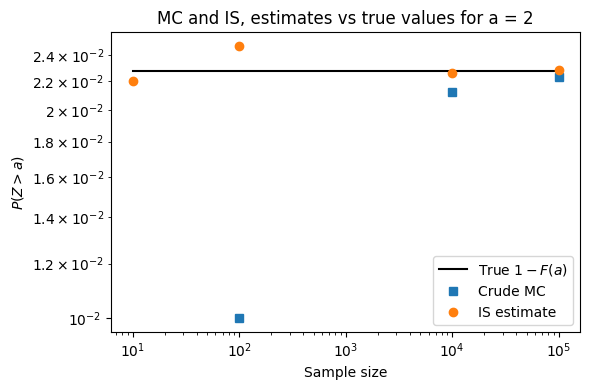

In [203]:

np.random.seed(30)
k = 4
atest = 2
sample_sizes = np.array([10, 100, 10_000, 100_000])
monte = np.zeros(k)
is_estimate = np.zeros(k)
correct = np.full(k, 1 - ss.norm.cdf(atest))

for i in range(k):
    monte[i], var      = Monte_carl_7(atest, sample_sizes[i])
    is_estimate[i], var = is_estimate_7(atest, sample_sizes[i])

plt.figure(figsize=(6, 4))
plt.plot(sample_sizes, correct, 'k-', label='True $1-F(a)$')
plt.plot(sample_sizes, monte, 's', label='Crude MC')
plt.plot(sample_sizes, is_estimate, 'o', label='IS estimate')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Sample size')
plt.ylabel('$P(Z > a)$')
plt.legend()
plt.title("MC and IS, estimates vs true values for a = 2")
plt.tight_layout()
plt.show()

# 8

In [192]:
def is_sampling(lam,N):
    Y = np.random.exponential(1/lam,size=N)    
    h = lambda x: np.exp(x)
    X = h(Y)*ss.uniform.pdf(Y)/ss.expon.pdf(Y, scale=1/lam)
    return np.mean(X),np.var(X,ddof=1)

In [193]:
F = lambda lam: 1/(lam**2*(2*lam+2))*(np.exp(2+lam)-1)

sp.optimize.minimize(F,x0=0.2)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 2.0195497522881585
        x: [ 2.705e+00]
      nit: 10
      jac: [-2.980e-08]
 hess_inv: [[ 1.468e+00]]
     nfev: 26
     njev: 13

In [194]:
is_sampling(1.355,10000)

(np.float64(1.7338053581831643), np.float64(3.205614244412048))

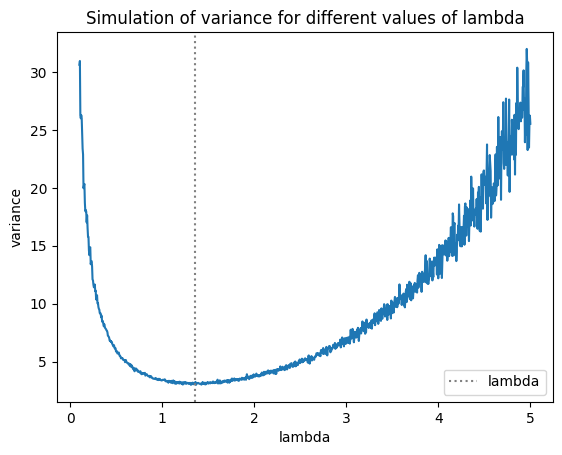

In [202]:
N = 1000
interval = np.linspace(0.1,5,N)
arr= np.zeros(N)
for i in range(0,len(interval)):
    _,arr[i]= is_sampling(interval[i],10000)


plt.plot(interval,arr)
plt.axvline(1.355, color="gray", ls=":", label="lambda")
plt.xlabel("lambda") 
plt.ylabel("variance")
plt.title("Simulation of variance for different values of lambda")
plt.legend()

# 9

In [196]:
def task9(k, beta, N):
    # a = k
    # m/x_m = beta 
    Y = (np.random.pareto(a=k-1, size=N) + 1) * beta   
    np.random.pareto
    h = lambda x: x
    X = h(Y) * ss.pareto.pdf(Y, b=k,  scale=beta) / ss.pareto.pdf(Y, b=k-1, scale=beta)
    return np.mean(X), np.var(X, ddof=1)

In [197]:
k = 10
beta = 222

mean,var = task9(k,beta,1000) 
correct_mean = k*beta/(k-1) # taget fra wiki

mean, correct_mean

(np.float64(246.66666666666663), 246.66666666666666)

# why is this good?

We want to esitmate the mean. Using the first momemnt(aka the mean), as the sampling we highligh the are we want to have, so Importance sampling, actually samples in the important area using first momemnt. 

For taking means, it can be generalized? IF you want to take the variance, then we need the second moment, as this is the importance space we want to sample.


for part 8, we need the mean, so lets set g(x) to the first moment distribution of the expontial distribution.

the first moment of the exp distribution is $\frac{1}{\lambda}$